Criatura Lendária: Cubo Gelatinoso
==================================

**Autor:** João Gabriel Coutinho Oliveira

## Introdução 

Este é um trabalho da disciplina de Aprendizado de Máquina, segundo período do bacharelado de Ciência e Tecnologia da Escola de Ciências ILUM. O objetivo deste trabalho é prever se uma pessoa teve um Stroke(Derrame), também conhecido como AVC (Acidente Vascular Cerebral), com base em dados como gênero, idade, índice de massa corporal, nível de glicose, tipo de residência, tipo de trabalho, se tem hipertensão, se tem doenças cardíacas, se já se casou e se é um fumante ativo. Para começar, é preciso importas as bibliotecas que serão ulitizadas no código:

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

## Dataset

Utilizarei um dataset importado do banco de dados Kaggle, Stroke Prediction Dataset. Vamos dar uma olhada nas primeiras linhas do dataset:

In [2]:
dataset = "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(dataset)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Um passo importante é saber se tem dados ausentes no dataset, por isso vamos verificar:

In [3]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Sabe-se agora que temos 201 dados faltando na coluna "bmi"(Índice de massa corporal), então vamos remover as linhas que estão incompletas:

In [4]:
df_limpo = df.dropna()
df_limpo

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Temos um dataframe de 4909 linhas e 12 colunas para começar os trabalhos.

## Análise Exploratória

Antes de treinar o modelo, vamos observar como a variável alvo e alguns atributos se relacionam no conjunto de dados.


### Distribuição das classes


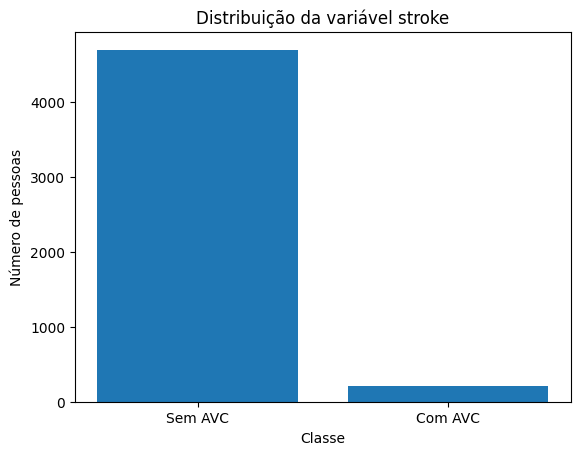

In [5]:
contagem_stroke = df_limpo["stroke"].value_counts().sort_index()

plt.bar(["Sem AVC", "Com AVC"], contagem_stroke)

plt.xlabel("Classe")
plt.ylabel("Número de pessoas")
plt.title("Distribuição da variável stroke")

plt.show()

O gráfico permite observar o desbalanceamento entre pessoas sem AVC e pessoas com AVC. Esse desbalanceamento será importante na interpretação das métricas do modelo.


### Idade e ocorrência de AVC


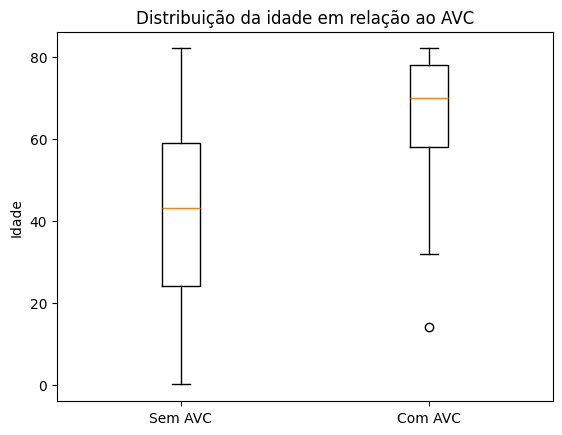

In [6]:
dados_sem_avc = df_limpo[df_limpo["stroke"] == 0]["age"]
dados_com_avc = df_limpo[df_limpo["stroke"] == 1]["age"]

plt.boxplot(
    [dados_sem_avc, dados_com_avc],
    tick_labels=["Sem AVC", "Com AVC"]
)

plt.ylabel("Idade")
plt.title("Distribuição da idade em relação ao AVC")

plt.show()

O boxplot permite comparar a distribuição das idades entre as duas classes, sem afirmar que a idade, isoladamente, determina a ocorrência de AVC.


### Glicose média e ocorrência de AVC


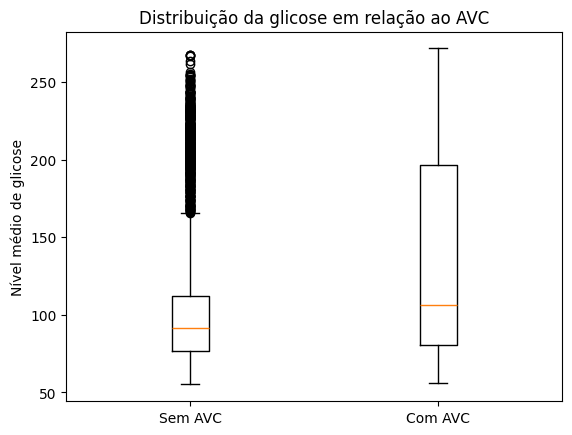

In [7]:
dados_sem_avc = df_limpo[df_limpo["stroke"] == 0]["avg_glucose_level"]
dados_com_avc = df_limpo[df_limpo["stroke"] == 1]["avg_glucose_level"]

plt.boxplot(
    [dados_sem_avc, dados_com_avc],
    tick_labels=["Sem AVC", "Com AVC"]
)

plt.ylabel("Nível médio de glicose")
plt.title("Distribuição da glicose em relação ao AVC")

plt.show()

Este gráfico compara a distribuição do nível médio de glicose entre as pessoas das duas classes.


### IMC e ocorrência de AVC


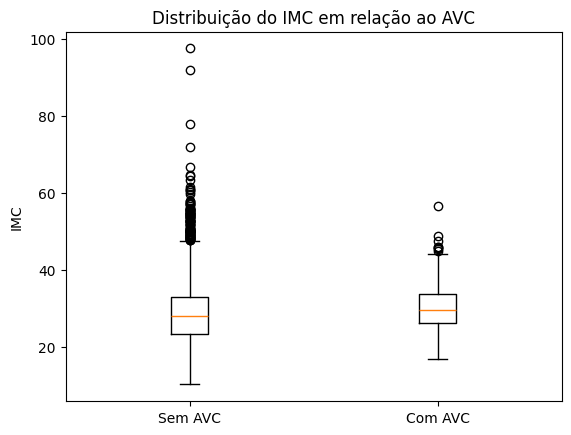

In [8]:
dados_sem_avc = df_limpo[df_limpo["stroke"] == 0]["bmi"]
dados_com_avc = df_limpo[df_limpo["stroke"] == 1]["bmi"]

plt.boxplot(
    [dados_sem_avc, dados_com_avc],
    tick_labels=["Sem AVC", "Com AVC"]
)

plt.ylabel("IMC")
plt.title("Distribuição do IMC em relação ao AVC")

plt.show()

O gráfico compara a distribuição do IMC entre as classes. Há sobreposição entre os grupos, portanto o IMC não deve ser interpretado isoladamente como determinante da ocorrência de AVC.


## Preparação dos dados

Primeiro precisamos definir qual vai ser o alvo do nosso modelo e os dados que ele vai se basear:

In [9]:
y = df_limpo["stroke"] # target
atributo = ["gender", "age", "hypertension", "heart_disease","ever_married","work_type","Residence_type","avg_glucose_level","bmi","smoking_status"]
x = df_limpo[atributo]

Com o nosso alvo definido, vamos precisar separar os dados entre os dados de treino, que serão utilizados para o treinamento do modelo, e os dados de teste, que serão usados para verificar a capacidade do nosso modelo de realizar as previsões. Para isso usamos o train_test_split do sklearn, informando os dados que serão divididos, a distribuição, o random_state (serve para que a divisão dos dados sejam o mesmo em todos as máquinas que rodarem o código) e o stratify, que informa a proporção da divisão com base na coluna alvo (stroke).

In [10]:
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 15,
    stratify = y
)


Como o nosso dataset possui dois tipos de dados, numéricos e categóricos, vamos tranformar os dados categóricos em dados numéricos fazendo a seguinte transformação:

In [11]:
scaler = StandardScaler() # normaliza valores numéricos
encoder = OneHotEncoder() # transforma valores string em numéricos

categoricas = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
numericas = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]

O `OneHotEncoder` transforma as variáveis categóricas em colunas numéricas. Já o `StandardScaler` padroniza as variáveis numéricas usando a média e o desvio padrão calculados no conjunto de treino. Isso é importante no KNN porque o algoritmo utiliza distâncias entre os exemplos, e variáveis em escalas muito diferentes podem influenciar excessivamente esse cálculo.


In [12]:
preprocessador_normalizado = ColumnTransformer(
    [
        ("categoricas", encoder, categoricas),
        ("numericas", scaler, numericas)
    ]
)

preprocessador_normalizado.fit(x_treino)

,transformers,"[('categoricas', ...), ('numericas', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


Agora normalizamos os dados de treino e de teste que o modelo usará.

In [13]:
x_treino_normalizado = preprocessador_normalizado.transform(x_treino)
x_teste_normalizado = preprocessador_normalizado.transform(x_teste)

## Experimentos com KNN

Começamos então a criação do modelo de predição:

In [14]:
knn = KNeighborsClassifier(n_neighbors = 5) #definindo o tipo de predição e quantidade de vizinhos
knn.fit(x_treino_normalizado, y_treino) #indicamos os dados que o modelo deve usar para aprender
y_pred = knn.predict(x_teste_normalizado) #colocamos o modelo para prever

Visualizaremos o resultado com uma matriz de confusão. Nessa matriz, a primeira linha e a primeira coluna representam o valor 0, enquanto a segunda linha e a segunda coluna representam o valor 1. 

In [15]:
confusion_matrix(y_teste, y_pred)

array([[934,   6],
       [ 41,   1]])

É possível ver que o modelo conseguiu prever 936 valores 0 corretos e 4 incorretos, enquanto o valor 1, ele acertou 2 e errou 40. Isso é uma coisa ruim, pois queremos que o modelo tenha mais acertos no valor 1.

Verificando alguns valores como acurácia, precisão, score f1 e recall, podemos ter uma ideia de desempenho do nosso modelo.

In [16]:
recall = recall_score(y_teste, y_pred)
acuracia = accuracy_score(y_teste, y_pred)
precisao = precision_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

print(f'Recall: {recall}. Acurácia: {acuracia}. Precisão: {precisao}. Score f1: {f1}.')

Recall: 0.023809523809523808. Acurácia: 0.9521384928716904. Precisão: 0.14285714285714285. Score f1: 0.04081632653061224.


Apesar de ter uma boa acurácia, ele tem um recall de apenas 4%, ou seja, ele não conseguiu prever bem as pessoas que tiveram AVC. Essa acurácia alta se deve por que ele conseguiu prever os valores 0.

Vamos colocar diferentes valores de vizinhos para ver como o modelo irá se sair. Colocamos valores impares para não ocorrer conflito.

In [17]:
valores_k = [1,3,5,7,9]
resultados_k = []

Cria-se o for para aplicar o teste do modelo em todos os k definidos acima:

In [18]:
for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k) #modelo
    modelo.fit(x_treino_normalizado, y_treino) #dados de treino do modelo
    previsoes = modelo.predict(x_teste_normalizado) #dados para prever o y
    recall = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    precisao = precision_score(y_teste, previsoes, zero_division = 0)
    acuracia = accuracy_score(y_teste, previsoes)
    resultados_k.append([k, acuracia, precisao, recall, f1])

Colocando em um DataFrame:

In [19]:
tabela_k = pd.DataFrame(
    resultados_k,
    columns=["k", "acuracia", "precisao", "recall", "f1"]
)
tabela_k

,k,acuracia,precisao,recall,f1
0,1,0.932790,0.100000,0.071429,0.083333
1,3,0.949084,0.100000,0.023810,0.038462
2,5,0.952138,0.142857,0.023810,0.040816
3,7,0.954175,0.000000,0.000000,0.000000
4,9,0.955193,0.000000,0.000000,0.000000


Na tabela, podemos ver que mesmo mudando os valores dos vizinhos, os resultados estão semelhantes ao teste inicial.

Vamos implementar mais um hiperparâmetro, as métricas, onde ele usará de diferente meios de medir a distância entre os k vizinhos.

In [20]:
metricas = ['euclidean', 'manhattan', 'chebyshev']
resultados_metricas = []

Faremos o teste dessas métricas com o valor de k vizinhos fixo em 5.

In [21]:
for metrica in metricas:
    modelo = KNeighborsClassifier(n_neighbors=5, metric=metrica) # modelo
    modelo.fit(x_treino_normalizado, y_treino) # dados de treino
    previsoes = modelo.predict(x_teste_normalizado) # previsão do modelo
    recall = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    precisao = precision_score(y_teste, previsoes, zero_division = 0)
    acuracia = accuracy_score(y_teste, previsoes)
    resultados_metricas.append(
        [metrica, acuracia, precisao, recall, f1]
    )

Colocamos em um DataFrame:

In [22]:
tabela_metricas = pd.DataFrame(
    resultados_metricas,
    columns=["metrica", "acuracia", "precisao", "recall", "f1"]
)

tabela_metricas

,metrica,acuracia,precisao,recall,f1
0,euclidean,0.952138,0.142857,0.02381,0.040816
1,manhattan,0.952138,0.142857,0.02381,0.040816
2,chebyshev,0.957230,0.000000,0.00000,0.000000


Podemos ver que os valores do euclidean e do manhattan são bem parecidos, enquanto o chebyshev somente teve o valor da acurácia.

## Efeito da normalização


Como o KNN utiliza distâncias, vamos comparar a mesma configuração do modelo com e sem normalização das variáveis numéricas.


In [23]:
preprocessador = ColumnTransformer(
    [
        ("categoricas", encoder, categoricas),
        ("numericas", "passthrough", numericas)
    ]
)

preprocessador.fit(x_treino)
x_treino_sem_normalizacao = preprocessador.transform(x_treino)
x_teste_sem_normalizacao = preprocessador.transform(x_teste)

In [24]:
# lista para guardar os resultados
resultados_normalizacao = []

# duas versões dos dados
conjuntos = [
    ("Com normalização", x_treino_normalizado, x_teste_normalizado),
    ("Sem normalização", x_treino_sem_normalizacao, x_teste_sem_normalizacao)
]

for nome, X_treino, X_teste in conjuntos:
    
    # mesma configuração do KNN para os dois casos
    modelo = KNeighborsClassifier(
        n_neighbors=5,
        metric="euclidean"
    )
    
    # treinamento
    modelo.fit(X_treino, y_treino)
    
    # previsão
    previsoes = modelo.predict(X_teste)
    
    # métricas
    acuracia = accuracy_score(y_teste, previsoes)
    precisao = precision_score(y_teste, previsoes, zero_division=0)
    recall = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    
    # guardar resultados
    resultados_normalizacao.append(
        [nome, acuracia, precisao, recall, f1]
    )

# transformar os resultados em tabela
tabela_normalizacao = pd.DataFrame(
    resultados_normalizacao,
    columns=["normalizacao", "acuracia", "precisao", "recall", "f1"]
)

tabela_normalizacao

,normalizacao,acuracia,precisao,recall,f1
0,Com normalização,0.952138,0.142857,0.02381,0.040816
1,Sem normalização,0.950102,0.000000,0.00000,0.000000


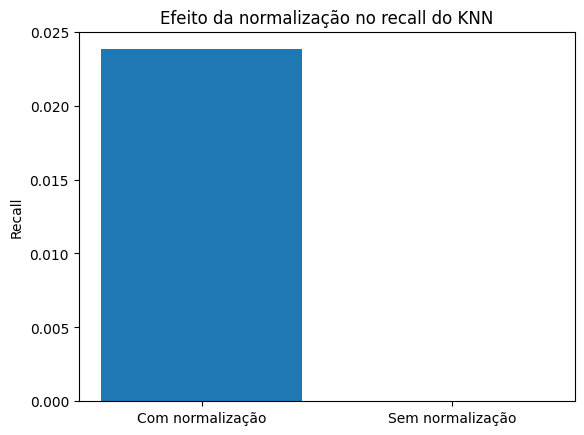

In [25]:
plt.bar(
    tabela_normalizacao["normalizacao"],
    tabela_normalizacao["recall"]
)

plt.ylabel("Recall")
plt.title("Efeito da normalização no recall do KNN")

plt.show()

O gráfico acima permite comparar diretamente o recall obtido com e sem normalização, mantendo a configuração do KNN igual nos dois casos.


## Modelo baseline

O baseline serve como uma referência simples para comparação. Aqui utilizamos `most_frequent`, que sempre prevê a classe mais frequente observada no conjunto de treino.


In [26]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(x_treino_normalizado, y_treino)


,strategy,'most_frequent'
,random_state,None
,constant,None


In [27]:
y_pred_baseline = baseline.predict(x_teste_normalizado)

In [28]:
np.unique(y_pred_baseline, return_counts=True)

(array([0]), array([982]))

In [29]:
acuracia_baseline = accuracy_score(y_teste, y_pred_baseline)

acuracia_baseline

0.9572301425661914

In [30]:
precisao_baseline = precision_score(
    y_teste,
    y_pred_baseline,
    zero_division=0
)

recall_baseline = recall_score(
    y_teste,
    y_pred_baseline
)

f1_baseline = f1_score(
    y_teste,
    y_pred_baseline
)

print("Precisão:", precisao_baseline)
print("Recall:", recall_baseline)
print("F1:", f1_baseline)

Precisão: 0.0
Recall: 0.0
F1: 0.0


### Comparações gráficas


In [31]:
tabela_k.sort_values(by="recall", ascending=False)

,k,acuracia,precisao,recall,f1
0,1,0.932790,0.100000,0.071429,0.083333
1,3,0.949084,0.100000,0.023810,0.038462
2,5,0.952138,0.142857,0.023810,0.040816
3,7,0.954175,0.000000,0.000000,0.000000
4,9,0.955193,0.000000,0.000000,0.000000


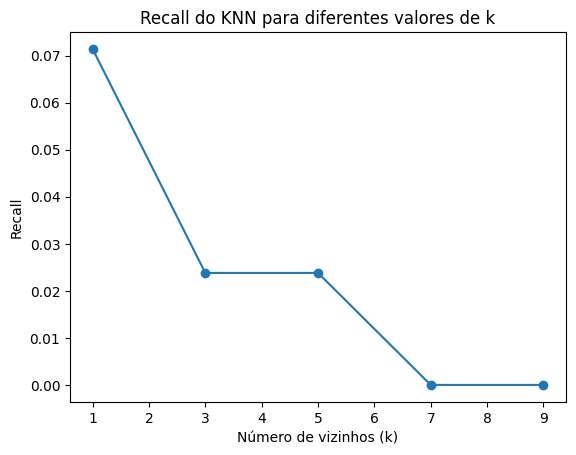

In [32]:
plt.plot(tabela_k["k"], tabela_k["recall"], marker="o")

plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Recall")
plt.title("Recall do KNN para diferentes valores de k")

plt.show()

In [33]:
modelos = ["Baseline", "KNN (k=5)"]

recalls = [
    recall_baseline,
    tabela_k.loc[tabela_k["k"] == 5, "recall"].iloc[0]
]

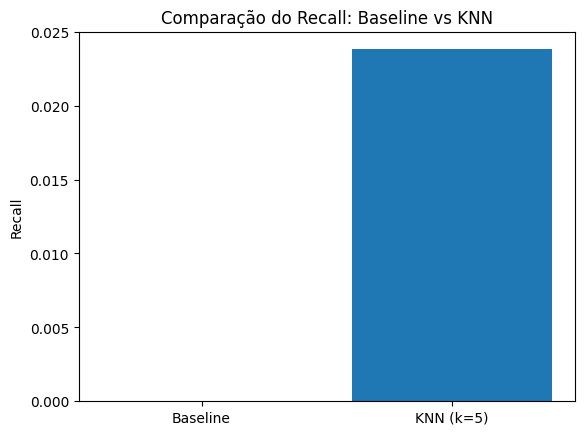

In [34]:
plt.bar(modelos, recalls)

plt.ylabel("Recall")
plt.title("Comparação do Recall: Baseline vs KNN")

plt.show()

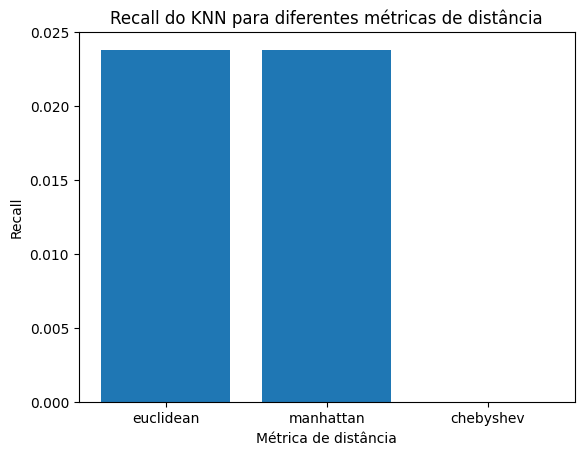

In [35]:
plt.bar(
    tabela_metricas["metrica"],
    tabela_metricas["recall"]
)

plt.xlabel("Métrica de distância")
plt.ylabel("Recall")
plt.title("Recall do KNN para diferentes métricas de distância")

plt.show()

## Análise dos resultados

## Conclusões e principais aprendizados

## Descrição do uso de IA neste trabalho

Neste trabalho, a IA foi utilizada para auxiliar no planejamento da elaboração do código.

## Referências

SORIANO, Federico. Stroke Prediction Dataset. Kaggle, 2021. Disponível em: <https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset>. Acesso em: 20 set. 2026.